# Exploratory Analysis of GitHub Repository Growth

## Objective
This project collects real-world data from the GitHub REST API and processes it through a structured data pipeline. The aim is to analyse repository popularity, contributor activity, and engagement using multiple analytical scenarios.

## Pipeline Stages
1. Data Acquisition (GitHub API)
2. Data Processing
3. Feature Engineering
4. Scenario-Based Analysis
5. Visualization

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
TOKEN = "*********************"

headers = {
    "Authorization": f"Bearer {TOKEN}"
}

repos = [
    "kubernetes/kubernetes",
    "pytorch/pytorch",
    "ansible/ansible",
    "scikit-learn/scikit-learn",
    "tensorflow/tensorflow",
    "apache/spark",
    "docker/compose",
    "prometheus/prometheus"
]

## 1: Data Acquisition Layer

In [7]:
def fetch_repo_data(repo):
    url = f"https://api.github.com/repos/{repo}"
    response = requests.get(url, headers=headers)
    return response.json()
    
def fetch_contributors(repo):
    url = f"https://api.github.com/repos/{repo}/contributors"
    response = requests.get(url, headers=headers)
    return len(response.json())

def fetch_commits(repo):
    url = f"https://api.github.com/repos/{repo}/commits"
    response = requests.get(url, headers=headers)
    return len(response.json())

## 2: Data Processing Layer

In [8]:
def process_repo(repo):
    data = fetch_repo_data(repo)

    return {
        "name": repo,
        "stars": data.get("stargazers_count", 0),
        "forks": data.get("forks_count", 0),
        "issues": data.get("open_issues_count", 0),
        "language": data.get("language"),
        "created_at": data.get("created_at"),
        "updated_at": data.get("updated_at"),
        "contributors": fetch_contributors(repo),
        "recent_commits": fetch_commits(repo)
    }
dataset = []
for repo in repos:
    try:
        dataset.append(process_repo(repo))
    except:
        print(f"Error processing {repo}")

In [9]:
df = pd.DataFrame(dataset)
df.head()
df.to_csv("github_data.csv", index=False)
print(df.head())

                        name   stars  forks  issues language  \
0      kubernetes/kubernetes  121396  42745    2641       Go   
1            pytorch/pytorch   98619  27319   18134   Python   
2            ansible/ansible   68392  24167     804   Python   
3  scikit-learn/scikit-learn   65543  26855    2150   Python   
4      tensorflow/tensorflow  194363  75254    4033      C++   

             created_at            updated_at  contributors  recent_commits  
0  2014-06-06T22:56:04Z  2026-03-27T14:48:55Z            30              30  
1  2016-08-13T05:26:41Z  2026-03-27T15:15:41Z            30              30  
2  2012-03-06T14:58:02Z  2026-03-27T12:36:20Z            30              30  
3  2010-08-17T09:43:38Z  2026-03-27T14:46:20Z            30              30  
4  2015-11-07T01:19:20Z  2026-03-27T15:03:29Z            30              30  


## Data Cleaning

In [10]:
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
df["updated_at"] = pd.to_datetime(df["updated_at"], utc=True)

# Use UTC time
df["age_days"] = (pd.Timestamp.now(tz="UTC") - df["created_at"]).dt.days

# Handle missing language
df["language"] = df["language"].fillna("Unknown")

## Basic Analysis

In [11]:
print(df.describe())
print(df["language"].value_counts())

               stars         forks        issues  contributors  \
count       8.000000      8.000000      8.000000           8.0   
mean    86486.250000  30188.875000   3613.625000          30.0   
std     51576.143388  21509.609065   6018.560624           0.0   
min     37214.000000   5761.000000     85.000000          30.0   
25%     58246.250000  20693.250000    646.000000          30.0   
50%     66967.500000  27087.000000   1477.000000          30.0   
75%    104313.250000  32539.750000   2989.000000          30.0   
max    194363.000000  75254.000000  18134.000000          30.0   

       recent_commits     age_days  
count             8.0     8.000000  
mean             30.0  4528.375000  
std               0.0   706.393848  
min              30.0  3513.000000  
25%              30.0  4181.500000  
50%              30.0  4452.000000  
75%              30.0  4936.750000  
max              30.0  5701.000000  
language
Go        3
Python    3
C++       1
Scala     1
Name: count, dt

## Popularity Analysis

In [12]:
df["stars_per_day"] = df["stars"] / df["age_days"]
df["forks_per_star"] = df["forks"] / df["stars"]
df["contributors_per_star"] = df["contributors"] / df["stars"]

df.sort_values("stars", ascending=False)[["name", "stars"]]

,name,stars
4,tensorflow/tensorflow,194363
0,kubernetes/kubernetes,121396
1,pytorch/pytorch,98619
2,ansible/ansible,68392
3,scikit-learn/scikit-learn,65543
7,prometheus/prometheus,63311
5,apache/spark,43052
6,docker/compose,37214


## Popularity Visualization

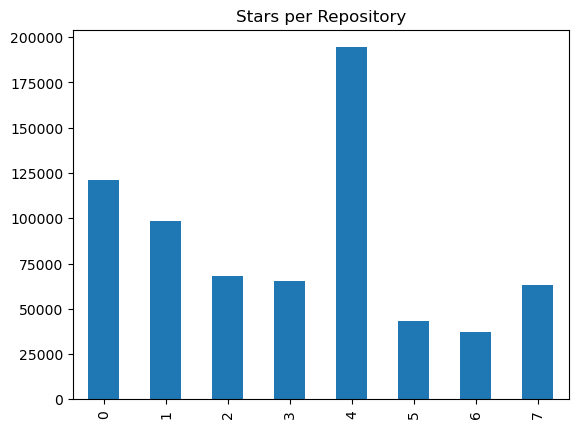

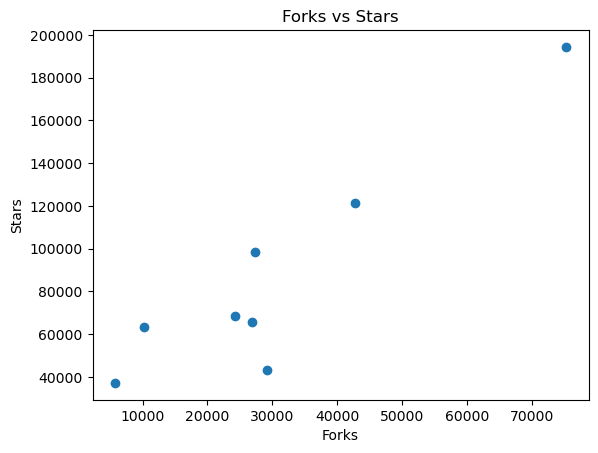

In [13]:
# Stars distribution
df["stars"].plot(kind="bar", title="Stars per Repository")
plt.show()

# Scatter plot
plt.scatter(df["forks"], df["stars"])
plt.xlabel("Forks")
plt.ylabel("Stars")
plt.title("Forks vs Stars")
plt.show()

1. Repositories with more forks tend to have more stars